# Verification: two-variable coefficient variance

This notebook verifies the coefficient-variance distribution for a genuine two-variable quantum Fourier model. The circuit input is $x=(x_1,x_2)$, not a shared scalar input. For $n=2$ qubits and $L=2$ upload layers, each variable uses exponential encoding prefactors $1$ and $3$, so the frequency spectrum is $[-4,4]^2$.

The trainable part uses PennyLane `StronglyEntanglingLayers` with $B=10$ repetitions. The initial sample count is intentionally small, `N_SAMPLES = 100`, so the notebook can be run quickly before increasing the sampling budget.

In [10]:
from __future__ import annotations

import itertools
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml
from matplotlib.lines import Line2D

ROOT = Path.cwd()
PAPER_WORK = ROOT / "Paper_work"
FIGURE_DIR = PAPER_WORK / "MSQE" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13,
    "axes.labelsize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 12,
})

In [11]:
# Main setting for the quick verification run.
N_QUBITS = 2
N_VARIABLES = 2
N_UPLOAD_LAYERS = 2
STRONG_ENTANGLE_BLOCKS = 5
N_SAMPLES = 30000
SEED = 2026
ENCODING_BASE = 3
DEVICE = "default.qubit"

MAX_COORDINATE_FREQUENCY = (ENCODING_BASE**N_UPLOAD_LAYERS - 1) // 2
N_GRID = 2 * MAX_COORDINATE_FREQUENCY + 1
GRID_POINTS = 2.0 * np.pi * np.arange(N_GRID) / N_GRID
FREQUENCY_VALUES = tuple(range(-MAX_COORDINATE_FREQUENCY, MAX_COORDINATE_FREQUENCY + 1))

print(
    f"setting: variables={N_VARIABLES} | qubits={N_QUBITS} | L={N_UPLOAD_LAYERS} | "
    f"B={STRONG_ENTANGLE_BLOCKS} | samples={N_SAMPLES}"
)
print(f"per-variable prefactors = {[ENCODING_BASE**layer for layer in range(N_UPLOAD_LAYERS)]}")
print(f"frequency spectrum Omega = [[-{MAX_COORDINATE_FREQUENCY}, {MAX_COORDINATE_FREQUENCY}]]^{N_VARIABLES}")
print(f"grid points per variable = {N_GRID}; total grid points = {N_GRID**N_VARIABLES}")

setting: variables=2 | qubits=2 | L=2 | B=5 | samples=30000
per-variable prefactors = [1, 3]
frequency spectrum Omega = [[-4, 4]]^2
grid points per variable = 9; total grid points = 81


In [12]:
dev = qml.device(DEVICE, wires=N_QUBITS)


@qml.qnode(dev, interface=None)
def two_variable_qfm(x, weights):
    wires = list(range(N_QUBITS))

    qml.StronglyEntanglingLayers(weights[0], wires=wires)
    for layer in range(N_UPLOAD_LAYERS):
        beta = ENCODING_BASE**layer
        for variable, wire in enumerate(wires):
            qml.RX(beta * x[variable], wires=wire)
        qml.StronglyEntanglingLayers(weights[layer + 1], wires=wires)

    return qml.probs(wires=wires)


def random_weights(rng):
    shape = (N_UPLOAD_LAYERS + 1, STRONG_ENTANGLE_BLOCKS, N_QUBITS, 3)
    return rng.uniform(0.0, 2.0 * np.pi, size=shape)


def model_value(x, weights):
    # Global projector observable |00><00|, matching the project's global qml.probs(...)[0] convention.
    return float(np.asarray(two_variable_qfm(np.asarray(x, dtype=float), weights))[0])

In [13]:
# Inspect the actual PennyLane tape angles for a two-variable input.
ANGLE_TEST_INPUT = np.array([0.1, 0.3], dtype=float)
ANGLE_TEST_WEIGHTS = np.zeros((N_UPLOAD_LAYERS + 1, STRONG_ENTANGLE_BLOCKS, N_QUBITS, 3), dtype=float)
angle_tape = qml.workflow.construct_tape(two_variable_qfm)(ANGLE_TEST_INPUT, ANGLE_TEST_WEIGHTS)

print("encoding rotation gates read from the PennyLane tape")
print(f"test input x = {ANGLE_TEST_INPUT}")
print("expected logic: layer beta in [1, 3], angle on wire j is beta * x_j")
print()

for op in angle_tape.operations:
    if op.name == "RX":
        angle = float(np.asarray(qml.math.toarray(op.parameters[0])))
        wire = int(list(op.wires)[0])
        print(
            f"gate={op.name}, wire={wire}, angle={angle:.12g}, "
            f"angle / x_wire={angle / ANGLE_TEST_INPUT[wire]:.12g}"
        )

encoding rotation gates read from the PennyLane tape
test input x = [0.1 0.3]
expected logic: layer beta in [1, 3], angle on wire j is beta * x_j

gate=RX, wire=0, angle=0.1, angle / x_wire=1
gate=RX, wire=1, angle=0.3, angle / x_wire=1
gate=RX, wire=0, angle=0.3, angle / x_wire=3
gate=RX, wire=1, angle=0.9, angle / x_wire=3


In [14]:
def coefficient_tensor(function_grid):
    # If f(x)=sum_omega c_omega exp(-i omega.x), ifftn gives c_omega on the integer grid.
    return np.fft.ifftn(function_grid)


def coefficient_at(coeffs, omega):
    return coeffs[tuple(int(w) % coeffs.shape[axis] for axis, w in enumerate(omega))]


def complex_sample_variance(samples, axis=0):
    samples = np.asarray(samples)
    return np.mean(np.abs(samples) ** 2, axis=axis) - np.abs(np.mean(samples, axis=axis)) ** 2


def hyperoctahedral_orbit(orbit_frequency):
    orbit_frequency = tuple(int(freq) for freq in orbit_frequency)
    orbit = set()
    for permuted in itertools.permutations(orbit_frequency):
        for signs in itertools.product((-1, 1), repeat=len(orbit_frequency)):
            orbit.add(tuple(0 if freq == 0 else sign * freq for sign, freq in zip(signs, permuted)))
    return sorted(orbit)


def orbit_frequency_spectrum(n_variables, max_coordinate_frequency):
    return list(itertools.combinations_with_replacement(range(max_coordinate_frequency + 1), n_variables))


def grouped_frequencies_by_orbit(n_variables, max_coordinate_frequency):
    frequency_set = set(itertools.product(range(-max_coordinate_frequency, max_coordinate_frequency + 1), repeat=n_variables))
    ordered = []
    spans = []
    for rep in orbit_frequency_spectrum(n_variables, max_coordinate_frequency):
        orbit = [omega for omega in hyperoctahedral_orbit(rep) if omega in frequency_set]
        orbit = sorted(orbit)
        if not orbit:
            continue
        start = len(ordered)
        ordered.extend(orbit)
        stop = len(ordered)
        spans.append({"rep": rep, "start": start, "stop": stop, "orbit": orbit})

    observed = set(ordered)
    if observed != frequency_set:
        missing = sorted(frequency_set - observed)[:10]
        extra = sorted(observed - frequency_set)[:10]
        raise RuntimeError(f"Orbit grouping mismatch. missing={missing}, extra={extra}")
    if len(ordered) != len(observed):
        raise RuntimeError("Orbit grouping produced duplicate frequencies.")
    return ordered, spans


orbit_ordered_frequencies, orbit_spans = grouped_frequencies_by_orbit(
    N_VARIABLES,
    MAX_COORDINATE_FREQUENCY,
)
print(f"number of frequencies = {len(orbit_ordered_frequencies)}")
print(f"number of hyperoctahedral orbits = {len(orbit_spans)}")
print(f"example orbit frequency (0, 1): {hyperoctahedral_orbit((0, 1))}")

number of frequencies = 81
number of hyperoctahedral orbits = 15
example orbit frequency (0, 1): [(-1, 0), (0, -1), (0, 1), (1, 0)]


In [15]:
def evaluate_function_grid(weights):
    values = np.empty((N_GRID,) * N_VARIABLES, dtype=float)
    for index in np.ndindex(values.shape):
        x = np.array([GRID_POINTS[i] for i in index], dtype=float)
        values[index] = model_value(x, weights)
    return values


def run_coefficient_variance_experiment():
    rng = np.random.default_rng(SEED)
    n_frequencies = len(orbit_ordered_frequencies)
    n_orbits = len(orbit_spans)
    coeff_samples = np.empty((N_SAMPLES, n_frequencies), dtype=np.complex128)
    orbit_sum_samples = np.empty((N_SAMPLES, n_orbits), dtype=np.complex128)

    start_time = time.perf_counter()
    for sample in range(N_SAMPLES):
        weights = random_weights(rng)
        function_grid = evaluate_function_grid(weights)
        coeffs = coefficient_tensor(function_grid)
        coeff_vector = np.array([coefficient_at(coeffs, omega) for omega in orbit_ordered_frequencies])
        coeff_samples[sample] = coeff_vector
        for orbit_index, span in enumerate(orbit_spans):
            orbit_sum_samples[sample, orbit_index] = coeff_vector[span["start"]:span["stop"]].sum()

        if (sample + 1) % max(1, N_SAMPLES // 5) == 0 or sample + 1 == N_SAMPLES:
            print(f"completed {sample + 1}/{N_SAMPLES} samples")

    coefficient_variances = np.maximum(complex_sample_variance(coeff_samples, axis=0).real, 0.0)
    orbit_variances = np.maximum(complex_sample_variance(orbit_sum_samples, axis=0).real, 0.0)
    orbit_sum_variances = np.array(
        [coefficient_variances[span["start"]:span["stop"]].sum() for span in orbit_spans],
        dtype=float,
    )

    elapsed = time.perf_counter() - start_time
    print(f"elapsed seconds = {elapsed:.2f}")
    print("orbit frequency | orbit size | sum Var(c_omega) | Var(a_nu) | Var(a_nu)/sum Var(c_omega)")
    for span, sum_var, a_var in zip(orbit_spans, orbit_sum_variances, orbit_variances):
        ratio = a_var / sum_var if sum_var > 0 else np.nan
        print(
            f"{span['rep']!s:>15s} | {span['stop'] - span['start']:10d} | "
            f"{sum_var:16.4e} | {a_var:9.4e} | {ratio:26.4f}"
        )

    return {
        "coefficient_samples": coeff_samples,
        "orbit_sum_samples": orbit_sum_samples,
        "coefficient_variances": coefficient_variances,
        "orbit_variances": orbit_variances,
        "orbit_sum_variances": orbit_sum_variances,
        "elapsed_seconds": elapsed,
    }


results = run_coefficient_variance_experiment()

completed 6000/30000 samples
completed 12000/30000 samples
completed 18000/30000 samples
completed 24000/30000 samples
completed 30000/30000 samples
elapsed seconds = 13683.71
orbit frequency | orbit size | sum Var(c_omega) | Var(a_nu) | Var(a_nu)/sum Var(c_omega)
         (0, 0) |          1 |       1.5242e-03 | 1.5242e-03 |                     1.0000
         (0, 1) |          4 |       4.0332e-03 | 4.0658e-03 |                     1.0081
         (0, 2) |          4 |       2.6614e-03 | 2.6409e-03 |                     0.9923
         (0, 3) |          4 |       3.9798e-03 | 3.9843e-03 |                     1.0011
         (0, 4) |          4 |       2.6719e-03 | 2.6781e-03 |                     1.0023
         (1, 1) |          4 |       2.0252e-03 | 2.0277e-03 |                     1.0012
         (1, 2) |          8 |       2.6632e-03 | 2.6749e-03 |                     1.0044
         (1, 3) |          8 |       5.2912e-03 | 5.3147e-03 |                     1.0044
         (1, 4)

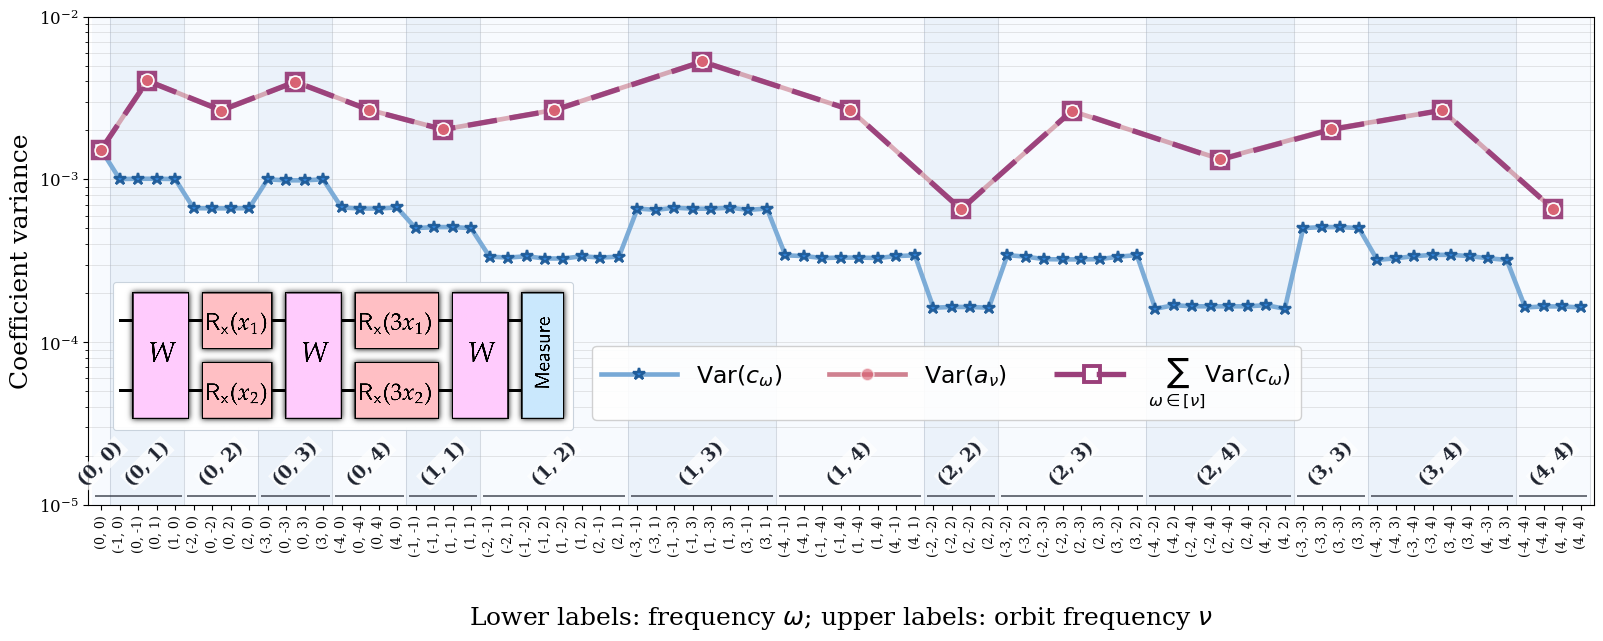

saved figure to /Users/letao/DataSpellProjects/quantum-fourier-expressivity/Paper_work/Paper_work/MSQE/figures/coefficient_variance_distribution_insert_2_L2_B5.png


In [16]:
# Inset figure: circuit diagram embedded in the coefficient-variance distribution.
# This cell reuses the already computed `results`; it does not rerun the PennyLane sampling.
import matplotlib.image as mpimg
from matplotlib.offsetbox import AnnotationBbox, OffsetImage


coefficient_variances = results["coefficient_variances"]
orbit_variances = results["orbit_variances"]
orbit_sum_variances = results["orbit_sum_variances"]

CIRCUIT_DIAGRAM_PATH = Path("/Users/letao/Desktop/ciruict_diagram.png")
OUTPUT_WITH_CIRCUIT_PATH = FIGURE_DIR / f"coefficient_variance_distribution_insert_{N_QUBITS}_L{N_UPLOAD_LAYERS}_B{STRONG_ENTANGLE_BLOCKS}.png"
CIRCUIT_INSET_ZOOM = 0.2
PROJECT_DISTRIBUTION_MAX_XTICK_LABELS = 121
PROJECT_DISTRIBUTION_MAX_ORBIT_LABELS = 45

if not CIRCUIT_DIAGRAM_PATH.exists():
    raise FileNotFoundError(f"Circuit diagram not found: {CIRCUIT_DIAGRAM_PATH}")

circuit_image = mpimg.imread(CIRCUIT_DIAGRAM_PATH)
x = np.arange(len(orbit_ordered_frequencies))
orbit_centers = np.array([0.5 * (span["start"] + span["stop"] - 1) for span in orbit_spans])

colors = {
    "coeff": "#1F5C99",
    "coeff_line": "#78A9D6",
    "coeff_marker": "#2D7DD2",
    "orbit": "#B63F55",
    "orbit_marker": "#D96272",
    "sum": "#9A3F7A",
    "sum_marker": "#C06A9A",
    "separator": "#AEB7C4",
    "band_even": "#F6FAFE",
    "band_odd": "#E7F0FA",
}

fig_width = min(24.0, max(10.8, 0.12 * len(orbit_ordered_frequencies) + 6.2))
fig, ax = plt.subplots(figsize=(fig_width, 6.3), constrained_layout=True)

for orbit_index, span in enumerate(orbit_spans):
    band_color = colors["band_even"] if orbit_index % 2 == 0 else colors["band_odd"]
    ax.axvspan(span["start"] - 0.5, span["stop"] - 0.5, color=band_color, alpha=0.82, linewidth=0, zorder=0)
    ax.axvline(span["stop"] - 0.5, color=colors["separator"], linewidth=0.75, alpha=0.48, zorder=1)

coeff_line_width = 3.3 if len(orbit_ordered_frequencies) <= 150 else 2.6

ax.plot(x, coefficient_variances, marker="*", linestyle="-", color=colors["coeff_line"], markerfacecolor=colors["coeff_marker"], markeredgecolor=colors["coeff"], markeredgewidth=1.7, linewidth=coeff_line_width, markersize=9, alpha=0.96, zorder=3, label=r"$\operatorname{Var}(c_\omega)$")
ax.plot(orbit_centers, orbit_variances, linestyle="-", color=colors["orbit"], linewidth=3.35, alpha=0.42, zorder=4)
ax.plot(orbit_centers, orbit_variances, linestyle="None", marker="o", color=colors["orbit"], markerfacecolor=colors["orbit_marker"], markeredgecolor="white", markeredgewidth=1.2, markersize=9.2, alpha=0.98, zorder=6, label=r"$\operatorname{Var}(a_\nu)$")
ax.plot(orbit_centers, orbit_sum_variances, marker="s", linestyle=(0, (5.5, 2.4)), color=colors["sum"], markerfacecolor="none", markeredgecolor=colors["sum"], markeredgewidth=3.2, linewidth=3.85, markersize=11.0, alpha=0.96, zorder=5, label=r"$\sum_{\omega\in[\nu]}\operatorname{Var}(c_\omega)$")

ax.set_yscale("log")
ax.set_ylim(1e-5, 1e-2)
ax.set_xlabel(r"Lower labels: frequency $\omega$; upper labels: orbit frequency $\nu$", fontsize=18, labelpad=34)
ax.set_ylabel("Coefficient variance", fontsize=18)
ax.grid(True, axis="y", which="both", linewidth=0.45, alpha=0.48)
ax.tick_params(axis="both", which="major", labelsize=12)
ax.set_xlim(-0.7, len(orbit_ordered_frequencies) - 0.3)

if len(orbit_spans) <= PROJECT_DISTRIBUTION_MAX_ORBIT_LABELS:
    for center, span in zip(orbit_centers, orbit_spans):
        left = span["start"] - 0.35
        right = span["stop"] - 0.65 if span["stop"] - span["start"] > 1 else span["stop"] - 0.35
        ax.hlines(0.018, left, right, transform=ax.get_xaxis_transform(), color="#2F3440", linewidth=1.15, alpha=0.85, clip_on=False)
        ax.text(center, 0.033, str(span["rep"]), transform=ax.get_xaxis_transform(), ha="center", va="bottom", rotation=45, fontsize=13, fontweight="semibold", color="#1F2430", bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.72, "pad": 0.8}, clip_on=False)

if len(orbit_ordered_frequencies) <= PROJECT_DISTRIBUTION_MAX_XTICK_LABELS:
    tick_positions = x
else:
    step = int(np.ceil(len(orbit_ordered_frequencies) / PROJECT_DISTRIBUTION_MAX_XTICK_LABELS))
    tick_positions = x[::step]
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(orbit_ordered_frequencies[int(i)]) for i in tick_positions], rotation=90, fontsize=9)

legend_handles = [
    Line2D([0], [0], color=colors["coeff_line"], marker="*", markerfacecolor=colors["coeff_marker"], markeredgecolor=colors["coeff"], markeredgewidth=1.7, linewidth=coeff_line_width, markersize=9, label=r"$\operatorname{Var}(c_\omega)$"),
    Line2D([0], [0], color=colors["orbit"], marker="o", markerfacecolor=colors["orbit_marker"], markeredgecolor="white", markeredgewidth=1.2, linewidth=3.35, alpha=0.65, markersize=9.2, label=r"$\operatorname{Var}(a_\nu)$"),
    Line2D([0], [0], color=colors["sum"], marker="s", markerfacecolor="none", markeredgecolor=colors["sum"], markeredgewidth=2.8, linewidth=3.85, linestyle=(0, (5.5, 2.4)), markersize=11.0, label=r"$\sum_{\omega\in[\nu]}\operatorname{Var}(c_\omega)$"),
]
ax.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.57, 0.15), ncol=3, fontsize=17, frameon=True, framealpha=0.9, handlelength=3.2)

circuit_inset = OffsetImage(circuit_image, zoom=CIRCUIT_INSET_ZOOM)
circuit_box = AnnotationBbox(
    circuit_inset,
    (0.32, 0.45),
    xycoords=ax.transAxes,
    box_alignment=(1.0, 1.0),
    frameon=True,
    bboxprops={"boxstyle": "round,pad=0.18", "facecolor": "white", "edgecolor": "#C7D1DB", "linewidth": 0.8, "alpha": 0.94},
    zorder=10,
)
ax.add_artist(circuit_box)

fig.savefig(OUTPUT_WITH_CIRCUIT_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(f"saved figure to {OUTPUT_WITH_CIRCUIT_PATH.resolve()}")

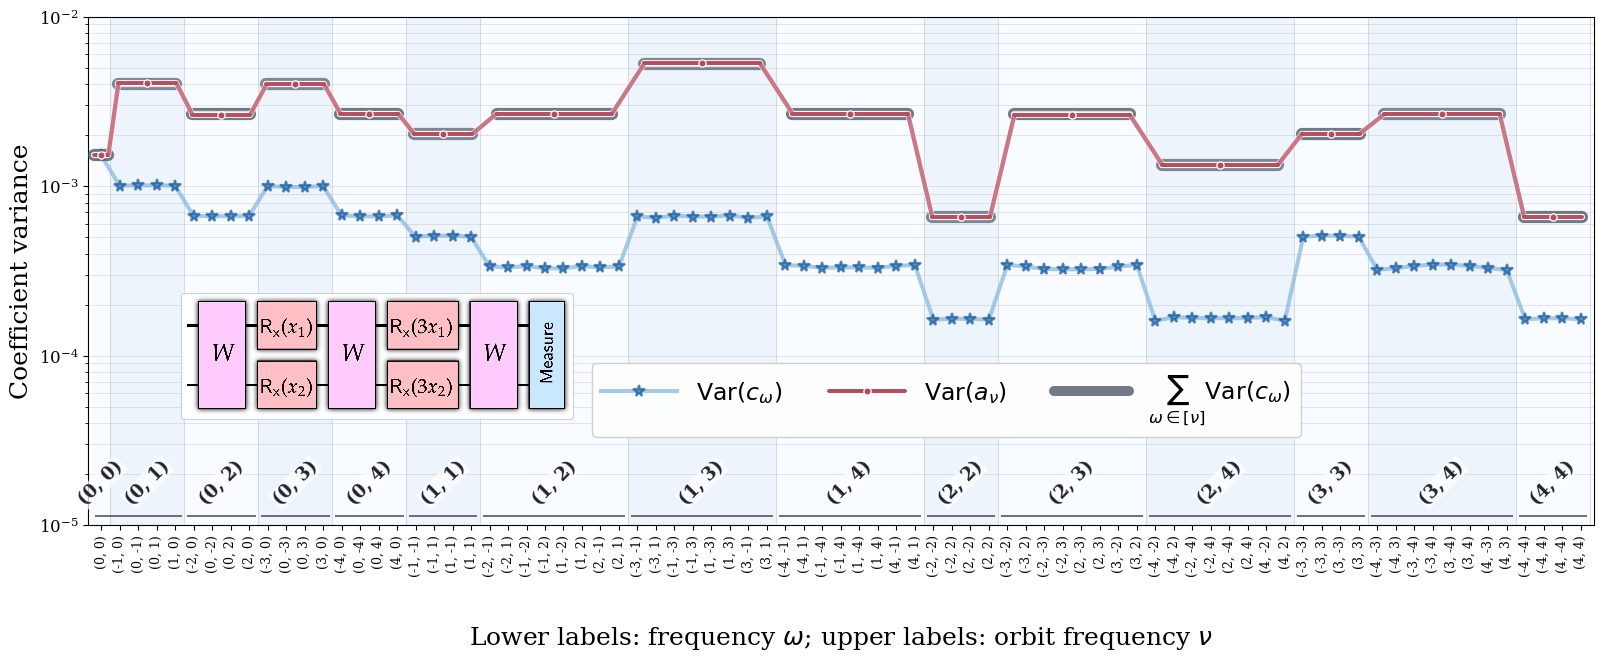

saved figure to /Users/letao/DataSpellProjects/quantum-fourier-expressivity/Paper_work/Paper_work/MSQE/figures/coefficient_variance_distribution_orbit_segments_insert_2_L2_B5.png


In [17]:
# Orbit-segment version: draw Var(a_nu) and sum Var(c_omega) as clean per-orbit line segments.
# This cell reuses the already computed `results`; it does not rerun the PennyLane sampling.
import matplotlib.image as mpimg
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnnotationBbox, OffsetImage


coefficient_variances = results["coefficient_variances"]
orbit_variances = results["orbit_variances"]
orbit_sum_variances = results["orbit_sum_variances"]

CIRCUIT_DIAGRAM_PATH = Path("/Users/letao/Desktop/ciruict_diagram.png")
OUTPUT_ORBIT_BAR_PATH = FIGURE_DIR / f"coefficient_variance_distribution_orbit_segments_insert_{N_QUBITS}_L{N_UPLOAD_LAYERS}_B{STRONG_ENTANGLE_BLOCKS}.png"
PROJECT_DISTRIBUTION_MAX_XTICK_LABELS = 121
PROJECT_DISTRIBUTION_MAX_ORBIT_LABELS = 45
CIRCUIT_INSET_ZOOM = 0.17

x = np.arange(len(orbit_ordered_frequencies))
orbit_centers = np.array([0.5 * (span["start"] + span["stop"] - 1) for span in orbit_spans])
orbit_widths = np.array([max(0.46, 0.78 * (span["stop"] - span["start"])) for span in orbit_spans])

colors = {
    "coeff": "#1F5C99",
    "coeff_line": "#86B7DE",
    "coeff_marker": "#2D7DD2",
    "orbit": "#B63F55",
    "separator": "#AEB7C4",
    "band_even": "#F7FBFF",
    "band_odd": "#EAF3FC",
}
sum_segment_colors = ["#4B5563", "#5E6877"]
a_segment_color = "#B84A5E"

fig_width = min(24.0, max(10.8, 0.12 * len(orbit_ordered_frequencies) + 6.2))
fig, ax = plt.subplots(figsize=(fig_width, 6.5), constrained_layout=True)

for orbit_index, span in enumerate(orbit_spans):
    band_color = colors["band_even"] if orbit_index % 2 == 0 else colors["band_odd"]
    ax.axvspan(span["start"] - 0.5, span["stop"] - 0.5, color=band_color, alpha=0.86, linewidth=0, zorder=0)
    ax.axvline(span["stop"] - 0.5, color=colors["separator"], linewidth=0.75, alpha=0.45, zorder=1)

coeff_line_width = 2.9 if len(orbit_ordered_frequencies) <= 150 else 2.4
ax.plot(
    x,
    coefficient_variances,
    marker="*",
    linestyle="-",
    color=colors["coeff_line"],
    markerfacecolor=colors["coeff_marker"],
    markeredgecolor=colors["coeff"],
    markeredgewidth=1.55,
    linewidth=coeff_line_width,
    markersize=8.4,
    alpha=0.72,
    zorder=3,
    label=r"$\operatorname{Var}(c_\omega)$",
)

previous_a_edge = None
for orbit_index, (center, width, a_var, sum_var) in enumerate(zip(orbit_centers, orbit_widths, orbit_variances, orbit_sum_variances)):
    left = center - 0.5 * width
    right = center + 0.5 * width
    sum_color = sum_segment_colors[orbit_index % len(sum_segment_colors)]

    ax.plot([left, right], [sum_var, sum_var], color=sum_color, linewidth=8.8, alpha=0.78, solid_capstyle="round", zorder=4)
    ax.plot([left, right], [sum_var, sum_var], color="#F3F5F8", linewidth=4.5, alpha=0.84, solid_capstyle="round", zorder=5)
    ax.plot([left, right], [sum_var, sum_var], color=sum_color, linewidth=1.35, alpha=0.98, solid_capstyle="round", zorder=6)

    if previous_a_edge is not None:
        previous_right, previous_a_var = previous_a_edge
        ax.plot([previous_right, left], [previous_a_var, a_var], color="white", linewidth=4.1, alpha=0.80, solid_capstyle="round", zorder=7)
        ax.plot([previous_right, left], [previous_a_var, a_var], color=a_segment_color, linewidth=3.15, alpha=0.74, solid_capstyle="round", zorder=8)

    ax.plot([left, right], [a_var, a_var], color="white", linewidth=4.25, alpha=0.90, solid_capstyle="round", zorder=7)
    ax.plot([left, right], [a_var, a_var], color=a_segment_color, linewidth=2.85, alpha=0.98, solid_capstyle="round", zorder=8)
    ax.plot(center, a_var, marker="o", markersize=5.2, markerfacecolor=a_segment_color, markeredgecolor="white", markeredgewidth=0.95, linestyle="None", zorder=9)
    previous_a_edge = (right, a_var)

ax.set_yscale("log")
ax.set_ylim(1e-5, 1e-2)
ax.set_xlabel(r"Lower labels: frequency $\omega$; upper labels: orbit frequency $\nu$", fontsize=18, labelpad=34)
ax.set_ylabel("Coefficient variance", fontsize=18)
ax.grid(True, axis="y", which="both", linewidth=0.45, alpha=0.48)
ax.tick_params(axis="both", which="major", labelsize=12)
ax.set_xlim(-0.7, len(orbit_ordered_frequencies) - 0.3)

if len(orbit_spans) <= PROJECT_DISTRIBUTION_MAX_ORBIT_LABELS:
    for center, span in zip(orbit_centers, orbit_spans):
        left = span["start"] - 0.35
        right = span["stop"] - 0.65 if span["stop"] - span["start"] > 1 else span["stop"] - 0.35
        ax.hlines(0.018, left, right, transform=ax.get_xaxis_transform(), color="#2F3440", linewidth=1.15, alpha=0.85, clip_on=False)
        ax.text(center, 0.033, str(span["rep"]), transform=ax.get_xaxis_transform(), ha="center", va="bottom", rotation=45, fontsize=13, fontweight="semibold", color="#1F2430", bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.72, "pad": 0.8}, clip_on=False)

if len(orbit_ordered_frequencies) <= PROJECT_DISTRIBUTION_MAX_XTICK_LABELS:
    tick_positions = x
else:
    step = int(np.ceil(len(orbit_ordered_frequencies) / PROJECT_DISTRIBUTION_MAX_XTICK_LABELS))
    tick_positions = x[::step]
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(orbit_ordered_frequencies[int(i)]) for i in tick_positions], rotation=90, fontsize=9)

legend_handles = [
    Line2D([0], [0], color=colors["coeff_line"], marker="*", markerfacecolor=colors["coeff_marker"], markeredgecolor=colors["coeff"], markeredgewidth=1.55, linewidth=coeff_line_width, markersize=8.4, alpha=0.72, label=r"$\operatorname{Var}(c_\omega)$"),
    Line2D([0], [0], color=a_segment_color, marker="o", markerfacecolor=a_segment_color, markeredgecolor="white", markeredgewidth=0.95, linewidth=2.85, markersize=5.2, solid_capstyle="round", label=r"$\operatorname{Var}(a_\nu)$"),
    Line2D([0], [0], color=sum_segment_colors[0], linewidth=7.2, alpha=0.78, solid_capstyle="round", label=r"$\sum_{\omega\in[\nu]}\operatorname{Var}(c_\omega)$"),
]
ax.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.57, 0.15), ncol=3, fontsize=17, frameon=True, framealpha=0.92, handlelength=3.2)

if CIRCUIT_DIAGRAM_PATH.exists():
    circuit_image = mpimg.imread(CIRCUIT_DIAGRAM_PATH)
    circuit_inset = OffsetImage(circuit_image, zoom=CIRCUIT_INSET_ZOOM)
    circuit_box = AnnotationBbox(
        circuit_inset,
        (0.32, 0.45),
        xycoords=ax.transAxes,
        box_alignment=(1.0, 1.0),
        frameon=True,
        bboxprops={"boxstyle": "round,pad=0.18", "facecolor": "white", "edgecolor": "#C7D1DB", "linewidth": 0.8, "alpha": 0.94},
        zorder=10,
    )
    ax.add_artist(circuit_box)
else:
    print(f"warning: circuit diagram not found: {CIRCUIT_DIAGRAM_PATH}")

fig.savefig(OUTPUT_ORBIT_BAR_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(f"saved figure to {OUTPUT_ORBIT_BAR_PATH.resolve()}")